In [23]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay


import numpy as np
import pandas as pd

In [3]:
CAMINHO_TRAIN = "C:\\Users\\Nitro\\Desktop\\Deep_Learning\\titanic_train.csv"
CAMINHO_TEST = "C:\\Users\\Nitro\\Desktop\\Deep_Learning\\titanic_test.csv"

# Tratamento de Base de Dados

In [4]:
train_data = pd.read_csv(CAMINHO_TRAIN)
test_data = pd.read_csv(CAMINHO_TEST)

dropped_test = test_data.dropna()

In [6]:
train_data.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
test_data.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, inplace=True)

In [7]:
le = LabelEncoder()
train_data["Sex"] = le.fit_transform(train_data["Sex"])
test_data["Sex"] = le.fit_transform(test_data["Sex"])

In [8]:
enc = OneHotEncoder(handle_unknown='ignore')

one_hot_encond_temp = pd.DataFrame(enc.fit_transform(train_data[["Embarked"]]).toarray())
train_data = train_data.iloc[:, :-1]
pd.concat([train_data, one_hot_encond_temp], axis=1, ignore_index=False)

one_hot_encond_temp = pd.DataFrame(enc.fit_transform(test_data[["Embarked"]]).toarray())
test_data = test_data.iloc[:, :-1]
pd.concat([test_data, one_hot_encond_temp], axis=1, ignore_index=False)

,Pclass,Sex,Age,SibSp,Parch,Fare,0,1,2
0,3,1,34.5,0,0,7.8292,0.0,1.0,0.0
1,3,0,47.0,1,0,7.0000,0.0,0.0,1.0
2,2,1,62.0,0,0,9.6875,0.0,1.0,0.0
3,3,1,27.0,0,0,8.6625,0.0,0.0,1.0
4,3,0,22.0,1,1,12.2875,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...
413,3,1,NaN,0,0,8.0500,0.0,0.0,1.0
414,1,0,39.0,0,0,108.9000,1.0,0.0,0.0
415,3,1,38.5,0,0,7.2500,0.0,0.0,1.0
416,3,1,NaN,0,0,8.0500,0.0,0.0,1.0


In [9]:
train_data.dropna(inplace=True)
test_data.dropna(inplace=True)

In [10]:
XTrain = train_data.iloc[:, 1:]
yTrain = train_data.iloc[:, 0]

XTest = test_data

XTrain

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,1,22.0,1,0,7.2500
1,1,0,38.0,1,0,71.2833
2,3,0,26.0,0,0,7.9250
3,1,0,35.0,1,0,53.1000
4,3,1,35.0,0,0,8.0500
...,...,...,...,...,...,...
885,3,0,39.0,0,5,29.1250
886,2,1,27.0,0,0,13.0000
887,1,0,19.0,0,0,30.0000
889,1,1,26.0,0,0,30.0000


In [11]:
sc = StandardScaler()
sc.fit(XTrain)

XTrain = sc.transform(XTrain.values)
XTest = sc.transform(XTest.values)

XTrain

C:\Users\Nitro\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\Users\Nitro\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[ 0.91123237,  0.75905134, -0.53037664,  0.52457013, -0.50589515,
        -0.51897787],
       [-1.47636364, -1.31743394,  0.57183099,  0.52457013, -0.50589515,
         0.69189675],
       [ 0.91123237, -1.31743394, -0.25482473, -0.55170307, -0.50589515,
        -0.50621356],
       ...,
       [-1.47636364, -1.31743394, -0.73704057, -0.55170307, -0.50589515,
        -0.08877362],
       [-1.47636364,  0.75905134, -0.25482473, -0.55170307, -0.50589515,
        -0.08877362],
       [ 0.91123237,  0.75905134,  0.15850313, -0.55170307, -0.50589515,
        -0.50952283]], shape=(714, 6))

# Rede Neural

In [13]:
ppn = Perceptron(max_iter=1000, eta0=0.1, random_state=0)
#usa SGD (comentar que atualiza os w para cada amostra e "sorteia" as amostras, permitindo melhor convergência na busca pelo mínimo global; fora que permite online learning)
#o batch gd (igual do vídeo passado) é bom para bases pequenas, mas ruim para bases grandes principalmente devido ao estouro de memória, fora que converge mais rápido
#minibatch tem características híbridas

ppn.fit(XTrain, yTrain)

,"penalty penalty: {'l2','l1','elasticnet'}, default=NoneThe penalty (aka regularization term) to be used.",None
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term if regularization isused.",0.0001
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with `0 <= l1_ratio <= 1`.`l1_ratio=0` corresponds to L2 penalty, `l1_ratio=1` to L1.Only used if `penalty='elasticnet'`... versionadded:: 0.24",0.15
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If False, thedata is assumed to be already centered.",True
,"max_iter max_iter: int, default=1000The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the ``fit`` method, and not the:meth:`partial_fit` method... versionadded:: 0.19",1000
,"tol tol: float or None, default=1e-3The stopping criterion. If it is not None, the iterations will stopwhen (loss > previous_loss - tol)... versionadded:: 0.19",0.001
,"shuffle shuffle: bool, default=TrueWhether or not the training data should be shuffled after each epoch.",True
,"verbose verbose: int, default=0The verbosity level.",0
,"eta0 eta0: float, default=1Constant by which the updates are multiplied.",0.1
,"n_jobs n_jobs: int, default=NoneThe number of CPUs to use to do the OVA (One Versus All, formulti-class problems) computation.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"random_state random_state: int, RandomState instance or None, default=0Used to shuffle the training data, when ``shuffle`` is set to``True``. Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary `.",0


In [14]:
yPred = ppn.predict(XTest)

In [16]:
y_test = pd.read_csv("C:\\Users\\Nitro\\Desktop\\Deep_Learning\\test_y.csv")
y_test.drop(dropped_test['PassengerId'].index, inplace=True)
y_test = y_test["Survived"].values

In [17]:
y_test

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1,

In [18]:
confusion_matrix(y_test, yPred)

array([[151,  72],
       [ 68,  40]])

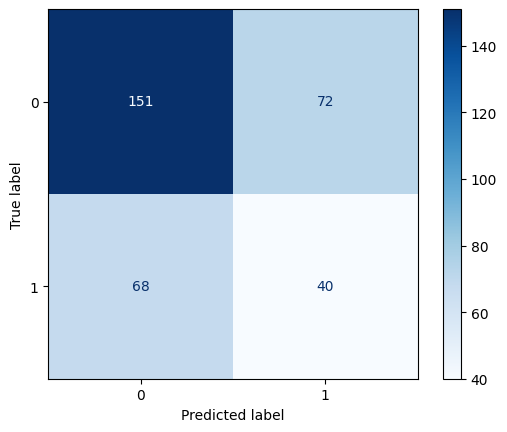

In [25]:
ConfusionMatrixDisplay.from_estimator(ppn, XTest, y_test, cmap="Blues")

In [26]:
accuracy_score(y_test, yPred)

0.5770392749244713

In [27]:
ppn.score(XTest, y_test)

0.5770392749244713

# Links Extras

https://www.youtube.com/playlist?list=PLeo1K3hjS3uu7CxAacxVndI4bE_o3BDtO
https://www.youtube.com/watch?v=aircAruvnKk
https://www.youtube.com/watch?v=c6NBkkKNZXw&list=PLxt59R_fWVzT9bDxA76AHm3ig0Gg9S3So&index=5
https://machinelearningmastery.com/implement-perceptron-algorithm-scratch-python/
https://scikit-learn.org/0.15/modules/generated/sklearn.linear_model.Perceptron.html
https://chrisalbon.com/machine_learning/basics/perceptron_in_scikit-learn/